# **PROYECTO FINAL- SINIESTROS VIALES 2015-2020 - SiniBogotá**

**CURSO SISTEMAS INTELIGENTES**

**Integrantes:**

*   Santiago Orjuela - santiago_orjuela@javeriana.edu.co
*   Laura Beltran Arias - beltranla@javeriana.edu.co
*   Cristhian Barrera - barrera_co@javeriana.edu.co




## **Planeación**

### Contexto:

La seguridad vial constituye uno de los principales retos de gestión pública en Bogotá, donde la alta densidad poblacional, el aumento en el uso de vehiculos y la diversidad de actores viales generan condiciones complejas de movilidad.

Para darnos una idea, entre 2021 y 2024, las muertes por siniestros viales en Bogotá presentaron un aumento sostenido, solo para 2025 se ha logrado una reducción cercana al 2% frente al 2024, esto segun estudios del Observatorio Nacional de Seguridad Vial. (11 Feb 2026, Bogota.Gov.co, Gina R Sánchez)

En adición, durante los últimos años, la ciudad ha experimentado eventos atípicos y restricciones sin precedentes, como las medidas de confinamiento por la pandemia de COVID-19, jornadas de “día sin carro”, protestas sociales y variaciones significativas en la movilidad urbana.


Estos eventos alteran drásticamente:

- El volumen de tráfico

- Los patrones de desplazamiento

- El comportamiento de los actores viales

- La capacidad de control por parte de las autoridades

Sin embargo, no es claro si estas variaciones generan reducciones sostenidas en la frecuencia de siniestros, cambios en la severidad de los mismos o efectos temporales o estructurales frente al comportamiento de los usuarios.

Por si fuera poco, aunque el Distrito impone miles de comparendos cada año como mecanismo de control y disuasión, no existe evidencia clara de su impacto real en la reducción de la siniestralidad.


### Fuentes de Datos:

**Set Principal**

Los datos de siniestros viales en Bogotá que cubren el periodo comprendido entre el 1 de enero de 2015 y el 31 de diciembre de 2020.


***Fuente:***
Secretaría Distrital de Movilidad

Este data set esta distribuido en cinco tablas:

1.   Siniestros: Detalles del Siniestro
2.   Actores Viales: Detalles de los actores viales afectados
3.   Vehiculos: Detalles de los vehiculos
4.   Hipotesis: Código causa
5.   Diccionario: Descripciones de los sets anteriores


**Datos Complementarios**

Tenemos los siguientes data sets complementarios:

1. **Calendario 2015-2020** Contiene el día de la semana, si es festivo, si hay día sin carro, si hay covid, si hay protesta o algun evento relevante.
Fuente: Creado manualmente.


2. **Clima 2015-2020** La fuente IDEAM aporta observaciones diarias de precipitación por estación en la ciudad de Bogotá, extrayendo datos en un período de tiempo del año 2015 al 2020.



**Nota:** Todos los datasets los hemos subido a Git hub.

## **Estrategia de Integración de Datos**

Para enriquecer el análisis utilizaremos una estrategia de unión por cada una de los sets de datos.  

**Estrategia de Integración** (Relaciones 1:N)

### Set Principal (Siniestros)

La base de datos de siniestros viales constituye el eje central del estudio, ya que contiene información detallada sobre la ocurrencia, severidad, localización y características de los accidentes en Bogotá.


- **Set Calendario:**
Relación: 1 a 1.
Cruce directo por FECHA para etiquetar el contexto de cada accidente.

- **Set de Vehículos:**
Relación: 1 a Varios. Un CODIGO_ACCIDENTE puede tener varios vehículos.

   Estrategia: Se debe decidir si se aplana la base (contar cuántos vehículos hubo por accidente) o si se mantiene el detalle para analizar fallas mecánicas por tipo de vehículo.

- **Set de Actor Vial:**
Relación: 1 a Varios. Un accidente involucra a varias personas con diferentes roles.

  Estrategia: Cruce por CODIGO_ACCIDENTE. Es vital para identificar, por ejemplo, cuántos heridos hubo por cada tipo de vehículo involucrado.

- **Set de Hipótesis:**
Relación: 1 a Varios. Un accidente puede tener múltiples causas (ej. Lluvia + Embriaguez).

### Set Complementario 1 (Calendario 2015-2020)

El calendario de eventos especiales y restricciones de movilidad permite contextualizar los siniestros dentro de dinámicas externas que alteran el comportamiento del tráfico y los patrones de desplazamiento urbano bajo un enfoque de caracter temporal.

- **Calendario 2015 a 2020:**
Relación: Varios a Varios. Permite identificar eventos importantes mediante el cruce de fechas para las cuales ocurrieron los siniestros (ej. Dia festivo, día sin carro, protestas, etc.).


### Set Complementario 2 (Clima 2015-2020)

La fuente IDEAM aporta observaciones diarias de precipitación por estación; para integrarlas con la unidad de análisis accidente, se construyen variables agregadas diarias a nivel ciudad.



In [2]:
# DICCIONARIO SINIESTRALIDAD

import pandas as pd

siniestros_data = {
    'Campo': [
        'CODIGO_ACCIDENTE', 'FECHA', 'HORA', 'GRAVEDAD', 'CLASE',
        'CHOQUE', 'OBJETO_FIJO', 'DIRECCION', 'CODIGO_LOCALIDAD', 'DISENO_LUGAR'
    ],
    'Tipo de Dato': [
        'String', 'Date', 'String', 'String', 'String',
        'String', 'String', 'String', 'String', 'String'
    ],
    'Descripción': [
        'ID único del siniestro',
        'Fecha del evento (DD/MM/AAAA)',
        'Hora del reporte del accidente',
        'Código Nivel de afectación (Muertos, Heridos, Daños)',
        'Código Tipo de accidente (Choque, Atropello, etc.)',
        'Código (Carro, Tren, Objetivo Fijo, Semoviente)',
        'Código Elemento chocado (Poste, árbol, semáforo, etc.)',
        'Ubicación de la colisión',
        'Identificador de la localidad en Bogotá',
        'Código Tipo de infraestructura (Intersección, tramo, puente, ect.)'
    ],
    'Ejemplo': [
        '4401438', '01/01/2015', '01:05:00', '2', '2',
        '1', '2', 'KR 64A-CL 2C 02', '16', '2'
    ]
}

df_siniestros_dictionary = pd.DataFrame(siniestros_data)


In [3]:

# Diccionario Actor Vial
actor_vial_data = {
    'Campo': [
        'CODIGO_ACCIDENTE', 'CODIGO_ACCIDENTADO', 'FECHA',
        'CONDICION', 'ESTADO', 'EDAD', 'SEXO', 'VEHICULO'
    ],
    'Tipo de Dato': [
        'String', 'String', 'Date',
        'String', 'String', 'String', 'String', 'String'
    ],
    'Descripción': [
        'ID único del siniestro (Llave de unión)',
        'ID único de la persona involucrada',
        'Fecha del evento (DD/MM/AAAA)',
        'Rol del actor (Conductor, Peatón, Pasajero, etc.)',
        'Gravedad física (Ileso, Herido, Muerto)',
        'Años de la persona involucrada',
        'Género del actor vial',
        'ID del vehículo asociado al actor'
    ],
    'Ejemplo': [
        '4401447', '2452576', '01/01/2015',
        'CONDUCTOR', 'ILESO', '44', 'FEMENINO', '4401447-1'
    ]
}

# Generar el DataFrame
df_actor_vial_dictionary = pd.DataFrame(actor_vial_data)


In [4]:
# Diccionario para la base de Vehículos
vehiculos_data = {
    'Campo': [
        'CODIGO_ACCIDENTE', 'FECHA', 'VEHICULO',
        'CLASE', 'SERVICIO', 'MODALIDAD', 'ENFUGA'
    ],
    'Tipo de Dato': [
        'String', 'Date', 'String',
        'String', 'String', 'String', 'String'
    ],
    'Descripción': [
        'ID único del siniestro (Llave de unión)',
        'Fecha del evento (DD/MM/AAAA)',
        'ID interno del vehículo en el accidente',
        'Código Tipo de vehículo (Automóvil, Bus, Camión, etc.)',
        'Código Tipo de servicio (Particular, Público, Diplomático)',
        'Código Tipo de transporte (Pasajeros, Carga, Escolar)',
        'Indica si el conductor huyó del lugar (S/N)'
    ],
    'Ejemplo': [
        '4401438', '01/01/2015', '4401438-1',
        '1', '2', '5', 'N'
    ]
}

df_vehiculos_dictionary = pd.DataFrame(vehiculos_data)


In [5]:
# Diccionario set de Hipótesis
hipotesis_data = {
    'Campo': [
        'CODIGO_ACCIDENTE', 'FECHA', 'CODIGO_CAUSA'
    ],
    'Tipo de Dato': [
        'String', 'Date', 'String'
    ],
    'Description': [
        'ID único del siniestro (Llave de unión)',
        'Fecha del evento (DD/MM/AAAA)',
        'Código de la causa probable del accidente'
    ],
    'Ejemplo': [
        '4401438', '01/01/2015', '112'
    ]
}

df_hipotesis_dictionary = pd.DataFrame(hipotesis_data)


In [6]:
# Diccionario maestro de códigos (mapeo de descripciones)
diccionario_maestro_data = {
    'Campo': [
        'HOJA', 'CAMPO', 'CODIGO', 'DESCRIPCION'
    ],
    'Tipo de Dato': [
        'String', 'String', 'String', 'String'
    ],
    'Descripción': [
        'Nombre de la tabla a la que pertenece el código',
        'Nombre de la columna que contiene el código',
        'Valor dentro de la base de datos',
        'Significado del código (ej. 1 = Con Muertos)'
    ],
    'Ejemplo': [
        'SINIESTROS', 'GRAVEDAD', '2', 'CON HERIDOS'
    ]
}

df_maestro_dictionary = pd.DataFrame(diccionario_maestro_data)


In [7]:
# DICCIONARIO CALENDARIO

data_dictionary = {
    'Campo': [
        'Fecha', 'Dia_Semana', 'Festivo', 'Dia_sin_carro',
        'Hubo_Protesta', 'Es_COVID', 'Hay_Evento', 'Nombre_Evento'
    ],
    'Tipo de Dato': [
        'Date', 'String', 'String', 'String',
        'String', 'String', 'String', 'String'
    ],
    'Descripción': [
        'Día del año (Llave de unión)',
        'Describe el día de la semana',
        'Flag de día Feriado',
        'Flag de día sin carro',
        'Flag de protesta',
        'Flag de restricciones sanitarias',
        'Flag de realización de Eventos o fechas importantes',
        'Descripción del evento'
    ],
    'Ejemplo': [
        '01/05/2018', 'Martes', 'SI', 'NO',
        'SI', 'NO', 'SI', 'Día del Trabajo'
    ]
}

df_calernario_dictionary = pd.DataFrame(data_dictionary)


In [8]:
# Diccionario Clima

clima_data = {
    'Campo': [
        'CodigoEstacion', 'NombreEstacion', 'Variable', 'Parametro',
        'Fecha', 'Unidad', 'Valor', 'NivelAprobacion'
    ],
    'Tipo de Dato': [
        'String', 'String', 'String', 'String',
        'Date', 'String', 'Float', 'String'
    ],
    'Descripción': [
        'Código único de la estación hidrometeorológica del IDEAM',
        'Nombre de la estación que reporta la observación',
        'Variable meteorológica observada (en este archivo: precipitación)',
        'Definición del parámetro reportado por el IDEAM',
        'Fecha del registro diario',
        'Unidad de medida del valor reportado',
        'Valor observado de precipitación para la fecha y estación',
        'Nivel de validación/calidad del dato reportado por el IDEAM'
    ],
    'Ejemplo': [
        '21201300', 'AUSTRALIA [21201300]', 'PRECIPITACION',
        'Día pluviométrico (convencional)', '01/01/2015', 'mm', '0.0', 'Definitivo'
    ]
}

df_clima_dictionary = pd.DataFrame(clima_data)

## **Diccionarios de Datos**

In [9]:
print("DICCIONARIO DE DATOS: SET SINIESTROS")
display(df_siniestros_dictionary)


DICCIONARIO DE DATOS: SET SINIESTROS


,Campo,Tipo de Dato,Descripción,Ejemplo
0,CODIGO_ACCIDENTE,String,ID único del siniestro,4401438
1,FECHA,Date,Fecha del evento (DD/MM/AAAA),01/01/2015
2,HORA,String,Hora del reporte del accidente,01:05:00
3,GRAVEDAD,String,"Código Nivel de afectación (Muertos, Heridos, ...",2
4,CLASE,String,"Código Tipo de accidente (Choque, Atropello, e...",2
5,CHOQUE,String,"Código (Carro, Tren, Objetivo Fijo, Semoviente)",1
6,OBJETO_FIJO,String,"Código Elemento chocado (Poste, árbol, semáfor...",2
7,DIRECCION,String,Ubicación de la colisión,KR 64A-CL 2C 02
8,CODIGO_LOCALIDAD,String,Identificador de la localidad en Bogotá,16
9,DISENO_LUGAR,String,"Código Tipo de infraestructura (Intersección, ...",2


In [10]:
print("DICCIONARIO DE DATOS: SET ACTOR VIAL")
display(df_actor_vial_dictionary)


DICCIONARIO DE DATOS: SET ACTOR VIAL


,Campo,Tipo de Dato,Descripción,Ejemplo
0,CODIGO_ACCIDENTE,String,ID único del siniestro (Llave de unión),4401447
1,CODIGO_ACCIDENTADO,String,ID único de la persona involucrada,2452576
2,FECHA,Date,Fecha del evento (DD/MM/AAAA),01/01/2015
3,CONDICION,String,"Rol del actor (Conductor, Peatón, Pasajero, etc.)",CONDUCTOR
4,ESTADO,String,"Gravedad física (Ileso, Herido, Muerto)",ILESO
5,EDAD,String,Años de la persona involucrada,44
6,SEXO,String,Género del actor vial,FEMENINO
7,VEHICULO,String,ID del vehículo asociado al actor,4401447-1


In [11]:
print("DICCIONARIO DE DATOS: SET VEHÍCULOS")
display(df_vehiculos_dictionary)


DICCIONARIO DE DATOS: SET VEHÍCULOS


,Campo,Tipo de Dato,Descripción,Ejemplo
0,CODIGO_ACCIDENTE,String,ID único del siniestro (Llave de unión),4401438
1,FECHA,Date,Fecha del evento (DD/MM/AAAA),01/01/2015
2,VEHICULO,String,ID interno del vehículo en el accidente,4401438-1
3,CLASE,String,"Código Tipo de vehículo (Automóvil, Bus, Camió...",1
4,SERVICIO,String,"Código Tipo de servicio (Particular, Público, ...",2
5,MODALIDAD,String,"Código Tipo de transporte (Pasajeros, Carga, E...",5
6,ENFUGA,String,Indica si el conductor huyó del lugar (S/N),N


In [12]:
print("DICCIONARIO DE DATOS: SET HIPÓTESIS")
display(df_hipotesis_dictionary)


DICCIONARIO DE DATOS: SET HIPÓTESIS


,Campo,Tipo de Dato,Description,Ejemplo
0,CODIGO_ACCIDENTE,String,ID único del siniestro (Llave de unión),4401438
1,FECHA,Date,Fecha del evento (DD/MM/AAAA),01/01/2015
2,CODIGO_CAUSA,String,Código de la causa probable del accidente,112


In [13]:
print("DICCIONARIO DE REFERENCIA: MAESTRO DE CÓDIGOS")
display(df_maestro_dictionary)

DICCIONARIO DE REFERENCIA: MAESTRO DE CÓDIGOS


,Campo,Tipo de Dato,Descripción,Ejemplo
0,HOJA,String,Nombre de la tabla a la que pertenece el código,SINIESTROS
1,CAMPO,String,Nombre de la columna que contiene el código,GRAVEDAD
2,CODIGO,String,Valor dentro de la base de datos,2
3,DESCRIPCION,String,Significado del código (ej. 1 = Con Muertos),CON HERIDOS


In [14]:
print("DICCIONARIO DE DATOS: CALENDARIO 2015-2020")
display(df_calernario_dictionary)

DICCIONARIO DE DATOS: CALENDARIO 2015-2020


,Campo,Tipo de Dato,Descripción,Ejemplo
0,Fecha,Date,Día del año (Llave de unión),01/05/2018
1,Dia_Semana,String,Describe el día de la semana,Martes
2,Festivo,String,Flag de día Feriado,SI
3,Dia_sin_carro,String,Flag de día sin carro,NO
4,Hubo_Protesta,String,Flag de protesta,SI
5,Es_COVID,String,Flag de restricciones sanitarias,NO
6,Hay_Evento,String,Flag de realización de Eventos o fechas import...,SI
7,Nombre_Evento,String,Descripción del evento,Día del Trabajo


In [15]:
# DICCIONARIO CLIMA
print("DICCIONARIO DE DATOS: CLIMA IDEAM 2015-2020")
df_clima_dictionary

DICCIONARIO DE DATOS: CLIMA IDEAM 2015-2020


,Campo,Tipo de Dato,Descripción,Ejemplo
0,CodigoEstacion,String,Código único de la estación hidrometeorológica...,21201300
1,NombreEstacion,String,Nombre de la estación que reporta la observación,AUSTRALIA [21201300]
2,Variable,String,Variable meteorológica observada (en este arch...,PRECIPITACION
3,Parametro,String,Definición del parámetro reportado por el IDEAM,Día pluviométrico (convencional)
4,Fecha,Date,Fecha del registro diario,01/01/2015
5,Unidad,String,Unidad de medida del valor reportado,mm
6,Valor,Float,Valor observado de precipitación para la fecha...,0.0
7,NivelAprobacion,String,Nivel de validación/calidad del dato reportado...,Definitivo


## **Carga de datos**

In [16]:
# SET DE SINIESTROS PRINCIPAL 2015-2020

url = 'https://raw.githubusercontent.com/barrercr/Calendario_2015_2020/refs/heads/main/siniestros.csv'
df_siniestros = pd.read_csv(url, sep=';')

# convertir FECHA correctamente como dia/mes/año
df_siniestros['FECHA'] = pd.to_datetime(
    df_siniestros['FECHA'],
    format='%d/%m/%Y',
    errors='coerce'
)

df_siniestros.head(12)


,CODIGO_ACCIDENTE,FECHA,HORA,GRAVEDAD,CLASE,CHOQUE,OBJETO_FIJO,DIRECCION,CODIGO_LOCALIDAD,DISENO_LUGAR
0,10451321,2018-06-11,00:15:00,1,2,NaN,NaN,AC 0-KR 0 2,3,1
1,4485323,2017-06-19,15:00:00,2,1,1.0,NaN,AC 01-KR 14 45,14,1
2,4479285,2017-04-20,12:00:00,3,1,1.0,NaN,AC 01-KR 18C 02,14,1
3,4482520,2017-05-21,11:50:00,3,1,1.0,NaN,AC 01-TR 17A 02,14,1
4,4485252,2017-06-18,11:30:00,3,1,1.0,NaN,AC 06-KR 24 02,14,1
5,4497235,2017-10-23,08:10:00,2,1,1.0,NaN,AC 06-KR 24 02,14,2
6,4478067,2017-04-06,13:30:00,3,1,1.0,NaN,AC 06-KR 26 02,14,1
7,4475643,2017-03-13,20:30:00,3,1,1.0,NaN,AC 09-KR 108 38,1,1
8,4471672,2017-02-03,07:15:00,3,1,1.0,NaN,AC 1-KR 10A 66,3,1
9,4502355,2017-12-11,15:41:00,1,2,NaN,NaN,AC 1-KR 11A 02,3,1


In [17]:
df_siniestros.count()

CODIGO_ACCIDENTE    196152
FECHA               196152
HORA                196152
GRAVEDAD            196152
CLASE               196152
CHOQUE              167910
OBJETO_FIJO           6689
DIRECCION           196152
CODIGO_LOCALIDAD    196152
DISENO_LUGAR        196152
dtype: int64

In [18]:
# SET DE ACTOR_VIAL 2015-2020

url = 'https://raw.githubusercontent.com/barrercr/Calendario_2015_2020/refs/heads/main/actor_vial.csv'
df_actor_vial = pd.read_csv(url, sep=';')
df_actor_vial['FECHA'] = pd.to_datetime(
    df_actor_vial['FECHA'],
    format='%d/%m/%Y',
    errors='coerce'
)
df_actor_vial.head(2)

,CODIGO_ACCIDENTE,CODIGO_ACCIDENTADO,FECHA,CONDICION,ESTADO,EDAD,SEXO,VEHICULO
0,4401447,2452576,2015-01-01,CONDUCTOR,ILESO,44,F,4401447-1
1,4401447,2452577,2015-01-01,CONDUCTOR,ILESO,31,M,4401447-2


In [19]:
df_actor_vial.count()

CODIGO_ACCIDENTE      422416
CODIGO_ACCIDENTADO    422416
FECHA                 422416
CONDICION             422416
ESTADO                422416
EDAD                  422416
SEXO                  422416
VEHICULO              398969
dtype: int64

In [20]:
# SET DE VEHICULOS 2015-2020

url = 'https://raw.githubusercontent.com/barrercr/Calendario_2015_2020/refs/heads/main/vehiculos.csv'
df_vehiculos = pd.read_csv(url, sep=';')
df_vehiculos['FECHA'] = pd.to_datetime(
    df_vehiculos['FECHA'],
    format='%d/%m/%Y',
    errors='coerce'
)
df_vehiculos.head(2)


,CODIGO_ACCIDENTE,FECHA,VEHICULO,CLASE,SERVICIO,MODALIDAD,ENFUGA
0,4401423,2015-01-01,4401423-1,1.0,2.0,5.0,N
1,4401423,2015-01-01,4401423-2,1.0,3.0,NaN,N


In [21]:
df_vehiculos.count()

CODIGO_ACCIDENTE    371605
FECHA               371605
VEHICULO            371605
CLASE               368751
SERVICIO            355918
MODALIDAD           143685
ENFUGA              371605
dtype: int64

In [22]:
# SET DE HIPOTESIS 2015-2020

url = 'https://raw.githubusercontent.com/barrercr/Calendario_2015_2020/refs/heads/main/hipotesis.csv'
df_hipotesis = pd.read_csv(url, sep=';')
df_hipotesis['FECHA'] = pd.to_datetime(
    df_hipotesis['FECHA'],
    format='%d/%m/%Y',
    errors='coerce'
)
df_hipotesis.head(2)

,CODIGO_ACCIDENTE,FECHA,CODIGO_CAUSA
0,4401425,2015-01-01,115
1,4401437,2015-01-01,104


In [23]:
df_hipotesis.count()

CODIGO_ACCIDENTE    233819
FECHA               233819
CODIGO_CAUSA        233819
dtype: int64

In [24]:
# SET DE DICCIONARIO MAESTRO 2015-2020

url = 'https://raw.githubusercontent.com/barrercr/Calendario_2015_2020/refs/heads/main/maestro_diccionario.csv'
df_diccionario_maestro = pd.read_csv(url, sep=';')
df_diccionario_maestro.head(10)


,HOJA,CAMPO,CODIGO,DESCRIPCION
0,SINIESTROS,GRAVEDAD,1,Con Muertos
1,SINIESTROS,GRAVEDAD,2,Con Heridos
2,SINIESTROS,GRAVEDAD,3,Solo Daños
3,SINIESTROS,CLASE,7,Autolesion
4,SINIESTROS,CLASE,1,Choque
5,SINIESTROS,CLASE,2,Atropello
6,SINIESTROS,CLASE,4,Caida de ocupante
7,SINIESTROS,CLASE,3,Volcamiento
8,SINIESTROS,CLASE,6,Otro
9,SINIESTROS,CLASE,5,Incendio


In [25]:
# SET DE DATOS CALENDARIO 2015-2020

url = 'https://raw.githubusercontent.com/barrercr/Calendario_2015_2020/refs/heads/main/Calendario_Bogota_2015_2020.csv'
df_calendario = pd.read_csv(url)

df_calendario['Fecha'] = pd.to_datetime(
    df_calendario['Fecha'],
    format='%d/%m/%Y',
    errors='coerce'
)

df_calendario.head(10)

,Fecha,Dia_Semana,Festivo,Dia_sin_carro,Hubo_Protesta,Es_COVID,Hay_Evento,Nombre_Evento
0,2015-01-01,Jueves,SI,NO,NO,NO,SI,Año Nuevo
1,2015-01-02,Viernes,NO,NO,NO,NO,NO,Sin_Registro
2,2015-01-03,Sábado,NO,NO,NO,NO,NO,Sin_Registro
3,2015-01-04,Domingo,NO,NO,NO,NO,NO,Sin_Registro
4,2015-01-05,Lunes,NO,NO,NO,NO,SI,Fiesta de Reyes - Carnaval de Bogota
5,2015-01-06,Martes,NO,NO,NO,NO,SI,Fiesta de Reyes - Carnaval de Bogota
6,2015-01-07,Miercoles,NO,NO,NO,NO,SI,Fiesta de Reyes - Carnaval de Bogota
7,2015-01-08,Jueves,NO,NO,NO,NO,SI,Fiesta de Reyes - Carnaval de Bogota
8,2015-01-09,Viernes,NO,NO,NO,NO,NO,Sin_Registro
9,2015-01-10,Sábado,NO,NO,NO,NO,NO,Sin_Registro


In [26]:
df_calendario.count()

Fecha            2192
Dia_Semana       2192
Festivo          2192
Dia_sin_carro    2192
Hubo_Protesta    2192
Es_COVID         2192
Hay_Evento       2192
Nombre_Evento    2186
dtype: int64

In [27]:
# SET DE DATOS CLIMA IDEAM 2015-2020 (precipitación)
url_clima = 'https://raw.githubusercontent.com/Vankold1/SiniBogota/refs/heads/main/descargaDhime.csv'

df_clima_raw = pd.read_csv(url_clima)
df_clima_raw.head(10)

,CodigoEstacion,NombreEstacion,Variable,Parametro,Fecha,Unidad,Valor,NivelAprobacion
0,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-01 00:00,mm,0.0,Definitivo
1,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-02 00:00,mm,0.0,Definitivo
2,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-03 00:00,mm,0.0,Definitivo
3,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-04 00:00,mm,0.0,Definitivo
4,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-05 00:00,mm,0.0,Definitivo
5,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-06 00:00,mm,0.0,Definitivo
6,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-07 00:00,mm,0.0,Definitivo
7,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-08 00:00,mm,0.0,Definitivo
8,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-09 00:00,mm,0.0,Definitivo
9,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-10 00:00,mm,0.0,Definitivo


In [28]:
# LIMPIEZA Y AGREGACIÓN DEL SET DE CLIMA

df_clima_raw.columns = [c.strip() for c in df_clima_raw.columns]

df_clima = df_clima_raw.copy()
df_clima['Fecha'] = pd.to_datetime(df_clima['Fecha'], errors='coerce')
df_clima['Variable'] = df_clima['Variable'].astype(str).str.strip().str.upper()
df_clima['Parametro'] = df_clima['Parametro'].astype(str).str.strip()
df_clima['NivelAprobacion'] = df_clima['NivelAprobacion'].astype(str).str.strip()
df_clima['Valor'] = pd.to_numeric(df_clima['Valor'], errors='coerce')

# Mantener únicamente precipitación válida
df_clima = df_clima[
    (df_clima['Variable'] == 'PRECIPITACION') &
    (df_clima['Fecha'].between('2015-01-01', '2020-12-31'))
].copy()

# Resumen por fecha a nivel Bogotá.
df_clima_bogota = (
    df_clima
    .groupby('Fecha', as_index=False)
    .agg(
        precip_promedio_bogota=('Valor', 'mean'),
        precip_max_bogota=('Valor', 'max'),
        precip_min_bogota=('Valor', 'min'),
        num_estaciones_reporte=('CodigoEstacion', 'nunique'),
        num_estaciones_lluvia=('Valor', lambda s: int((s.fillna(0) > 0).sum()))
    )
)

df_clima_bogota['pct_estaciones_lluvia'] = (
    df_clima_bogota['num_estaciones_lluvia'] /
    df_clima_bogota['num_estaciones_reporte'].replace(0, pd.NA)
)

df_clima_bogota.head(10)

,Fecha,precip_promedio_bogota,precip_max_bogota,precip_min_bogota,num_estaciones_reporte,num_estaciones_lluvia,pct_estaciones_lluvia
0,2015-01-01,0.00,0.0,0.0,1,0,0.0
1,2015-01-02,0.25,0.5,0.0,2,1,0.5
2,2015-01-03,0.00,0.0,0.0,1,0,0.0
3,2015-01-04,0.00,0.0,0.0,1,0,0.0
4,2015-01-05,0.00,0.0,0.0,1,0,0.0
5,2015-01-06,0.00,0.0,0.0,1,0,0.0
6,2015-01-07,0.00,0.0,0.0,1,0,0.0
7,2015-01-08,0.50,1.0,0.0,2,1,0.5
8,2015-01-09,0.00,0.0,0.0,1,0,0.0
9,2015-01-10,0.15,0.3,0.0,2,1,0.5


In [29]:
# CALIDAD Y COBERTURA DEL SET DE CLIMA

df_clima_estaciones = (
    df_clima
    .groupby(['CodigoEstacion', 'NombreEstacion'], as_index=False)
    .agg(
        fecha_min=('Fecha', 'min'),
        fecha_max=('Fecha', 'max'),
        registros=('Fecha', 'size'),
        precip_promedio=('Valor', 'mean')
    )
)

df_clima_estaciones['dias_esperados'] = (
    (df_clima_estaciones['fecha_max'] - df_clima_estaciones['fecha_min']).dt.days + 1
)
df_clima_estaciones['cobertura'] = (
    df_clima_estaciones['registros'] / df_clima_estaciones['dias_esperados']
)

print("Número de estaciones:", df_clima['CodigoEstacion'].nunique())
print("Cobertura promedio entre estaciones:", round(df_clima_estaciones['cobertura'].mean(), 3))
df_clima_estaciones.sort_values('cobertura', ascending=False)

Número de estaciones: 9
Cobertura promedio entre estaciones: 0.618


,CodigoEstacion,NombreEstacion,fecha_min,fecha_max,registros,precip_promedio,dias_esperados,cobertura
2,21201300,AUSTRALIA [21201300],2015-01-01,2020-12-31,2192,3.187819,2192,1.000000
8,35020350,BETANIA [35020350],2015-01-02,2020-12-31,1810,4.265028,2191,0.826107
6,21206650,COLEGIO SAN CAYETANO [21206650],2016-01-07,2020-12-30,1195,4.442762,1820,0.656593
4,21206260,C.UNIV.AGROP-UDCA [21206260],2015-01-16,2020-12-17,1250,3.862640,2163,0.577901
5,21206560,INEM KENNEDY [21206560],2015-01-16,2020-03-16,998,3.544990,1887,0.528882
1,21201230,ENMANUEL D' ALZON [21201230],2015-01-13,2020-12-31,1121,4.469135,2180,0.514220
3,21205791,EL DORADO CATAM [21205791],2015-01-15,2016-04-12,229,3.094323,454,0.504405
7,21206690,COLEGIO MIGUEL A. CARO [21206690],2015-01-15,2020-12-31,1064,3.701598,2178,0.488522
0,21201200,ESCUELA LA UNION [21201200],2015-01-17,2020-12-19,1010,3.058317,2164,0.466728


In [30]:
# EJEMPLO DE INTEGRACIÓN CON SINIESTROS
# Se une por FECHA diaria, porque el clima está agregado por día.

df_siniestros_modelo = df_siniestros.copy()
df_siniestros_modelo['FECHA'] = pd.to_datetime(
    df_siniestros_modelo['FECHA'],
    errors='coerce'
).dt.normalize()

df_clima_bogota['Fecha'] = pd.to_datetime(
    df_clima_bogota['Fecha'],
    errors='coerce'
).dt.normalize()

df_calendario['Fecha'] = pd.to_datetime(
    df_calendario['Fecha'],
    errors='coerce'
).dt.normalize()

# unión siniestros + clima
df_siniestros_clima = df_siniestros_modelo.merge(
    df_clima_bogota,
    how='left',
    left_on='FECHA',
    right_on='Fecha'
).drop(columns=['Fecha'])

# unión siniestros + calendario
df_siniestros_clima_cal = df_siniestros_clima.merge(
    df_calendario,
    how='left',
    left_on='FECHA',
    right_on='Fecha'
).drop(columns=['Fecha'])

df_siniestros_clima_cal.head(10)

,CODIGO_ACCIDENTE,FECHA,HORA,GRAVEDAD,CLASE,CHOQUE,OBJETO_FIJO,DIRECCION,CODIGO_LOCALIDAD,DISENO_LUGAR,...,num_estaciones_reporte,num_estaciones_lluvia,pct_estaciones_lluvia,Dia_Semana,Festivo,Dia_sin_carro,Hubo_Protesta,Es_COVID,Hay_Evento,Nombre_Evento
0,10451321,2018-06-11,00:15:00,1,2,NaN,NaN,AC 0-KR 0 2,3,1,...,7,7,1.000000,Lunes,SI,NO,NO,NO,NO,Sin_Registro
1,4485323,2017-06-19,15:00:00,2,1,1.0,NaN,AC 01-KR 14 45,14,1,...,6,4,0.666667,Lunes,SI,NO,NO,NO,NO,Sin_Registro
2,4479285,2017-04-20,12:00:00,3,1,1.0,NaN,AC 01-KR 18C 02,14,1,...,8,8,1.000000,Jueves,NO,NO,NO,NO,SI,Feria del Libro
3,4482520,2017-05-21,11:50:00,3,1,1.0,NaN,AC 01-TR 17A 02,14,1,...,8,7,0.875000,Domingo,NO,NO,NO,NO,NO,Sin_Registro
4,4485252,2017-06-18,11:30:00,3,1,1.0,NaN,AC 06-KR 24 02,14,1,...,7,6,0.857143,Domingo,NO,NO,NO,NO,SI,Dia del Padre
5,4497235,2017-10-23,08:10:00,2,1,1.0,NaN,AC 06-KR 24 02,14,2,...,2,0,0.000000,Lunes,NO,NO,NO,NO,SI,Festival de Cine
6,4478067,2017-04-06,13:30:00,3,1,1.0,NaN,AC 06-KR 26 02,14,1,...,2,1,0.500000,Jueves,NO,NO,NO,NO,NO,Sin_Registro
7,4475643,2017-03-13,20:30:00,3,1,1.0,NaN,AC 09-KR 108 38,1,1,...,7,6,0.857143,Lunes,NO,NO,NO,NO,NO,Sin_Registro
8,4471672,2017-02-03,07:15:00,3,1,1.0,NaN,AC 1-KR 10A 66,3,1,...,1,0,0.000000,Viernes,NO,NO,NO,NO,NO,Sin_Registro
9,4502355,2017-12-11,15:41:00,1,2,NaN,NaN,AC 1-KR 11A 02,3,1,...,3,1,0.333333,Lunes,NO,NO,NO,NO,SI,Alumbrados navideños Bogota


In [31]:
print("Rango fechas siniestros:", df_siniestros_modelo['FECHA'].min(), "->", df_siniestros_modelo['FECHA'].max())
print("Rango fechas clima:", df_clima_bogota['Fecha'].min(), "->", df_clima_bogota['Fecha'].max())
print("Rango fechas calendario:", df_calendario['Fecha'].min(), "->", df_calendario['Fecha'].max())

print("\nNulos en FECHA siniestros:", df_siniestros_modelo['FECHA'].isna().sum())
print("Nulos en clima unido:", df_siniestros_clima_cal['precip_promedio_bogota'].isna().sum())
print("Nulos en calendario unido:", df_siniestros_clima_cal['Dia_Semana'].isna().sum())

Rango fechas siniestros: 2015-01-01 00:00:00 -> 2020-12-31 00:00:00
Rango fechas clima: 2015-01-01 00:00:00 -> 2020-12-31 00:00:00
Rango fechas calendario: 2015-01-01 00:00:00 -> 2020-12-31 00:00:00

Nulos en FECHA siniestros: 0
Nulos en clima unido: 0
Nulos en calendario unido: 0


In [32]:
df_clima_bogota.count()

Fecha                     2192
precip_promedio_bogota    2192
precip_max_bogota         2192
precip_min_bogota         2192
num_estaciones_reporte    2192
num_estaciones_lluvia     2192
pct_estaciones_lluvia     2192
dtype: int64

## **Análisis exploratorio de los datos**

In [33]:
# LIBRERIAS
import pip

print('Installing ydata-profiling...')
pip.main(['install', 'ydata-profiling', '-q'])

import numpy as np
from collections import Counter
import re

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import LabelEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score



Installing ydata-profiling...


Please see https://github.com/pypa/pip/issues/5599 for advice on fixing the underlying issue.
To avoid this problem you can invoke Python with '-m pip' instead of running pip directly.


Informe Analisis Univariado y Multivariado




In [ ]:
from ydata_profiling import ProfileReport
calendario_report = ProfileReport(df_calendario, title="calendario Dataset Report")
calendario_report

## **Construcción dataset final**

In [34]:
df_modelo = df_siniestros_clima_cal.copy()

Bloque unificado de agregación

In [35]:
# -------------------------
# 1. AGREGADOS DE ACTOR VIAL
# -------------------------

df_actor_vial['EDAD'] = pd.to_numeric(df_actor_vial['EDAD'], errors='coerce')

df_actor_agg = df_actor_vial.groupby('CODIGO_ACCIDENTE').agg(
    num_actores=('CODIGO_ACCIDENTADO', 'count'),
    edad_promedio_actor=('EDAD', 'mean'),
    edad_min_actor=('EDAD', 'min'),
    edad_max_actor=('EDAD', 'max'),
    num_hombres=('SEXO', lambda x: (x.astype(str).str.upper() == 'M').sum()),
    num_mujeres=('SEXO', lambda x: (x.astype(str).str.upper() == 'F').sum()),
    condicion_principal=('CONDICION', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
    estado_principal_actor=('ESTADO', lambda x: x.mode().iloc[0] if not x.mode().empty else None)
).reset_index()

# -------------------------
# 2. AGREGADOS DE VEHÍCULOS
# -------------------------

df_vehiculos_agg = df_vehiculos.groupby('CODIGO_ACCIDENTE').agg(
    num_vehiculos=('VEHICULO', 'count'),
    clase_vehiculo_principal=('CLASE', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
    servicio_principal=('SERVICIO', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
    modalidad_principal=('MODALIDAD', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
    num_en_fuga=('ENFUGA', lambda x: (x.astype(str).str.upper() == 'S').sum())
).reset_index()

# -------------------------
# 3. AGREGADOS DE HIPÓTESIS / CAUSAS
# -------------------------

df_hipotesis['CODIGO_CAUSA'] = pd.to_numeric(df_hipotesis['CODIGO_CAUSA'], errors='coerce')

df_hipotesis_agg = df_hipotesis.groupby('CODIGO_ACCIDENTE').agg(
    codigo_causa_principal=('CODIGO_CAUSA', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
    num_causas_registradas=('CODIGO_CAUSA', 'count')
).reset_index()

# -------------------------
# 4. MERGES HACIA LA TABLA FINAL
# -------------------------

df_modelo = df_modelo.merge(df_actor_agg, on='CODIGO_ACCIDENTE', how='left')
df_modelo = df_modelo.merge(df_vehiculos_agg, on='CODIGO_ACCIDENTE', how='left')
df_modelo = df_modelo.merge(df_hipotesis_agg, on='CODIGO_ACCIDENTE', how='left')

**Definición variable objetivo**

Problema de clasificación supervisada, predecir la gravedad del accidente.

*Variable `GRAVEDAD` :*

1 → Con Muertos

2 → Con Heridos

3 → Solo Daños

*Variable objetivo binaria*

1 y 2 → 1 (Grave)

3 → 0 (No grave)

In [36]:
df_modelo['GRAVEDAD'] = pd.to_numeric(df_modelo['GRAVEDAD'], errors='coerce')

df_modelo['GRAVEDAD_BIN'] = df_modelo['GRAVEDAD'].map({
    1: 1,  # Con muertos
    2: 1,  # Con heridos
    3: 0   # Solo daños
})

Limpieza básica de nulos en variables derivadas

In [37]:
cols_ceros = [
    'num_actores',
    'num_vehiculos',
    'num_hombres',
    'num_mujeres',
    'num_en_fuga',
    'num_causas_registradas'
]

for col in cols_ceros:
    df_modelo[col] = df_modelo[col].fillna(0)

# variables numéricas derivadas
cols_numericas = [
    'edad_promedio_actor',
    'edad_min_actor',
    'edad_max_actor'
]

for col in cols_numericas:
    df_modelo[col] = df_modelo[col].fillna(df_modelo[col].median())

df_modelo.head()

,CODIGO_ACCIDENTE,FECHA,HORA,GRAVEDAD,CLASE,CHOQUE,OBJETO_FIJO,DIRECCION,CODIGO_LOCALIDAD,DISENO_LUGAR,...,condicion_principal,estado_principal_actor,num_vehiculos,clase_vehiculo_principal,servicio_principal,modalidad_principal,num_en_fuga,codigo_causa_principal,num_causas_registradas,GRAVEDAD_BIN
0,10451321,2018-06-11,00:15:00,1,2,NaN,NaN,AC 0-KR 0 2,3,1,...,CONDUCTOR,ILESO,1.0,NaN,NaN,NaN,1.0,157.0,1.0,1
1,4485323,2017-06-19,15:00:00,2,1,1.0,NaN,AC 01-KR 14 45,14,1,...,CONDUCTOR,HERIDO,2.0,1.0,3.0,NaN,0.0,103.0,1.0,1
2,4479285,2017-04-20,12:00:00,3,1,1.0,NaN,AC 01-KR 18C 02,14,1,...,CONDUCTOR,ILESO,2.0,1.0,2.0,7.0,0.0,103.0,1.0,0
3,4482520,2017-05-21,11:50:00,3,1,1.0,NaN,AC 01-TR 17A 02,14,1,...,CONDUCTOR,ILESO,2.0,1.0,2.0,5.0,0.0,103.0,1.0,0
4,4485252,2017-06-18,11:30:00,3,1,1.0,NaN,AC 06-KR 24 02,14,1,...,CONDUCTOR,ILESO,2.0,4.0,2.0,11.0,0.0,121.0,1.0,0


In [38]:
#Verificación de columnas finales
df_modelo.columns.tolist()

['CODIGO_ACCIDENTE',
 'FECHA',
 'HORA',
 'GRAVEDAD',
 'CLASE',
 'CHOQUE',
 'OBJETO_FIJO',
 'DIRECCION',
 'CODIGO_LOCALIDAD',
 'DISENO_LUGAR',
 'precip_promedio_bogota',
 'precip_max_bogota',
 'precip_min_bogota',
 'num_estaciones_reporte',
 'num_estaciones_lluvia',
 'pct_estaciones_lluvia',
 'Dia_Semana',
 'Festivo',
 'Dia_sin_carro',
 'Hubo_Protesta',
 'Es_COVID',
 'Hay_Evento',
 'Nombre_Evento',
 'num_actores',
 'edad_promedio_actor',
 'edad_min_actor',
 'edad_max_actor',
 'num_hombres',
 'num_mujeres',
 'condicion_principal',
 'estado_principal_actor',
 'num_vehiculos',
 'clase_vehiculo_principal',
 'servicio_principal',
 'modalidad_principal',
 'num_en_fuga',
 'codigo_causa_principal',
 'num_causas_registradas',
 'GRAVEDAD_BIN']

Verificación de ensamble del dataset final:

In [39]:
print("Filas df_siniestros:", df_siniestros.shape[0])
print("Filas df_modelo:", df_modelo.shape[0])

print("\n¿Se mantuvo una fila por accidente?")
print(df_modelo['CODIGO_ACCIDENTE'].nunique(), "accidentes únicos")
print(df_modelo.shape[0], "filas totales")

print("\nDistribución de GRAVEDAD:")
print(df_modelo['GRAVEDAD'].value_counts(dropna=False).sort_index())

print("\nDistribución de GRAVEDAD_BIN:")
print(df_modelo['GRAVEDAD_BIN'].value_counts(dropna=False))
print(df_modelo['GRAVEDAD_BIN'].value_counts(normalize=True, dropna=False))

Filas df_siniestros: 196152
Filas df_modelo: 196152

¿Se mantuvo una fila por accidente?
196152 accidentes únicos
196152 filas totales

Distribución de GRAVEDAD:
GRAVEDAD
1      2995
2     65238
3    127919
Name: count, dtype: int64

Distribución de GRAVEDAD_BIN:
GRAVEDAD_BIN
0    127919
1     68233
Name: count, dtype: int64
GRAVEDAD_BIN
0    0.652142
1    0.347858
Name: proportion, dtype: float64


## **Preparación de datos**

Se procedió a la exclusión selectiva de variables para garantizar la robustez del modelo, bajo los siguientes criterios:

- Eliminación de identificadores: Se descartó `CODIGO_ACCIDENTE` por carecer de valor predictivo al ser un registro único de carácter administrativo.
- Prevención de Data Leakage: Se excluyeron `GRAVEDAD` y `estado_principal_actor`. Esta última describe consecuencias del accidente (ej. lesionado, muerto), lo que introduciría un sesgo de anticipación del resultado.
- Aislamiento del Target: La variable `GRAVEDAD_BIN` se segmentó como el vector objetivo (y), separándola del conjunto de predictores (X).
- Reducción de ruido y cardinalidad: Las variables de texto libre, `DIRECCION` y `Nombre_Evento`, fueron omitidas debido a su alta cardinalidad y la complejidad técnica para su vectorización, evitando así la introducción de ruido innecesario en el entrenamiento.

In [40]:
# Selección de variables para modelado
y = df_modelo['GRAVEDAD_BIN']

cols_excluir = [
    'CODIGO_ACCIDENTE',
    'GRAVEDAD',
    'GRAVEDAD_BIN',
    'DIRECCION',
    'Nombre_Evento',
    'estado_principal_actor' 
]

X = df_modelo.drop(columns=cols_excluir)

print("Columnas finales:", X.columns.tolist())
print("Shape X:", X.shape)

Columnas finales: ['FECHA', 'HORA', 'CLASE', 'CHOQUE', 'OBJETO_FIJO', 'CODIGO_LOCALIDAD', 'DISENO_LUGAR', 'precip_promedio_bogota', 'precip_max_bogota', 'precip_min_bogota', 'num_estaciones_reporte', 'num_estaciones_lluvia', 'pct_estaciones_lluvia', 'Dia_Semana', 'Festivo', 'Dia_sin_carro', 'Hubo_Protesta', 'Es_COVID', 'Hay_Evento', 'num_actores', 'edad_promedio_actor', 'edad_min_actor', 'edad_max_actor', 'num_hombres', 'num_mujeres', 'condicion_principal', 'num_vehiculos', 'clase_vehiculo_principal', 'servicio_principal', 'modalidad_principal', 'num_en_fuga', 'codigo_causa_principal', 'num_causas_registradas']
Shape X: (196152, 33)


In [41]:
# Ajuste HORA esta como tiempo se convierte a número
X['HORA'] = pd.to_datetime(X['HORA'], format='%H:%M:%S', errors='coerce').dt.hour

In [42]:
# Extraer variables desde FECHA
X['mes'] = pd.to_datetime(X['FECHA'], errors='coerce').dt.month
X['dia_mes'] = pd.to_datetime(X['FECHA'], errors='coerce').dt.day
X['anio'] = pd.to_datetime(X['FECHA'], errors='coerce').dt.year
X['dia_anio'] = pd.to_datetime(X['FECHA'], errors='coerce').dt.dayofyear

In [43]:
# Eliminar FECHA original
X = X.drop(columns=['FECHA'])

In [44]:
print(X[['mes', 'dia_mes', 'anio', 'dia_anio']].head())
print(X[['mes', 'dia_mes', 'anio', 'dia_anio']].dtypes)

   mes  dia_mes  anio  dia_anio
0    6       11  2018       162
1    6       19  2017       170
2    4       20  2017       110
3    5       21  2017       141
4    6       18  2017       169
mes         int32
dia_mes     int32
anio        int32
dia_anio    int32
dtype: object


Separar variables numéricas y categóricas

In [45]:
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: ['HORA', 'CLASE', 'CHOQUE', 'OBJETO_FIJO', 'CODIGO_LOCALIDAD', 'DISENO_LUGAR', 'precip_promedio_bogota', 'precip_max_bogota', 'precip_min_bogota', 'num_estaciones_reporte', 'num_estaciones_lluvia', 'pct_estaciones_lluvia', 'num_actores', 'edad_promedio_actor', 'edad_min_actor', 'edad_max_actor', 'num_hombres', 'num_mujeres', 'num_vehiculos', 'clase_vehiculo_principal', 'servicio_principal', 'modalidad_principal', 'num_en_fuga', 'codigo_causa_principal', 'num_causas_registradas', 'mes', 'dia_mes', 'anio', 'dia_anio']
Categóricas: ['Dia_Semana', 'Festivo', 'Dia_sin_carro', 'Hubo_Protesta', 'Es_COVID', 'Hay_Evento', 'condicion_principal']


In [46]:
#Transformación de variables binarias (SI/NO) a 1/0
cols_binarias = [
    'Festivo',
    'Dia_sin_carro',
    'Hubo_Protesta',
    'Es_COVID',
    'Hay_Evento'
]

# Comprobar ANTES de mapping
print("BEFORE mapping:")
for col in cols_binarias:
    print(f"  {col}: unique={X[col].unique()}, NaN={X[col].isna().sum()}")

# Aplica mapping con fillna para gestionar cualquier valor inesperado
for col in cols_binarias:
    X[col] = X[col].map({'SI': 1, 'NO': 0}).fillna(0)  # Fill NaN with 0 as default

# Comprobar DESPUES de mapping
print("\nAFTER mapping:")
for col in cols_binarias:
    print(f"  {col}: unique={X[col].unique()}, NaN={X[col].isna().sum()}")

BEFORE mapping:
  Festivo: unique=['SI' 'NO'], NaN=0
  Dia_sin_carro: unique=['NO' 'SI'], NaN=0
  Hubo_Protesta: unique=['NO' 'SI'], NaN=0
  Es_COVID: unique=['NO' 'SI'], NaN=0
  Hay_Evento: unique=['NO' 'SI'], NaN=0

AFTER mapping:
  Festivo: unique=[1 0], NaN=0
  Dia_sin_carro: unique=[0 1], NaN=0
  Hubo_Protesta: unique=[0 1], NaN=0
  Es_COVID: unique=[0 1], NaN=0
  Hay_Evento: unique=[0 1], NaN=0


In [47]:
# Comprobar valores únicos en columnas binarias ANTES de mapping
print("Unique values in binary columns BEFORE mapping:")
cols_binarias = [
    'Festivo',
    'Dia_sin_carro',
    'Hubo_Protesta',
    'Es_COVID',
    'Hay_Evento'
]

for col in cols_binarias:
    if col in X.columns:
        unique_vals = X[col].unique()
        null_count = X[col].isna().sum()
        print(f"\n{col}:")
        print(f"  Unique values: {unique_vals}")
        print(f"  NaN count: {null_count}")
    else:
        print(f"\n{col}: COLUMN NOT FOUND!")

Unique values in binary columns BEFORE mapping:

Festivo:
  Unique values: [1 0]
  NaN count: 0

Dia_sin_carro:
  Unique values: [0 1]
  NaN count: 0

Hubo_Protesta:
  Unique values: [0 1]
  NaN count: 0

Es_COVID:
  Unique values: [0 1]
  NaN count: 0

Hay_Evento:
  Unique values: [0 1]
  NaN count: 0


In [48]:
# Comprueba si estas columnas existen en df_siniestros_clima_cal (the merged data antes de X)
print("Checking df_siniestros_clima_cal columns:")
if 'df_siniestros_clima_cal' in dir():
    print(f"Shape: {df_siniestros_clima_cal.shape}")
    print(f"Columns: {df_siniestros_clima_cal.columns.tolist()}")
    print("\nSample of calendar-event columns:")
    for col in ['Festivo', 'Dia_sin_carro', 'Hubo_Protesta', 'Es_COVID', 'Hay_Evento']:
        if col in df_siniestros_clima_cal.columns:
            print(f"  {col}: {df_siniestros_clima_cal[col].unique()[:5]}, NaN: {df_siniestros_clima_cal[col].isna().sum()}")
        else:
            print(f"  {col}: NOT IN DATAFRAME")
else:
    print("df_siniestros_clima_cal not found")

Checking df_siniestros_clima_cal columns:
Shape: (196152, 23)
Columns: ['CODIGO_ACCIDENTE', 'FECHA', 'HORA', 'GRAVEDAD', 'CLASE', 'CHOQUE', 'OBJETO_FIJO', 'DIRECCION', 'CODIGO_LOCALIDAD', 'DISENO_LUGAR', 'precip_promedio_bogota', 'precip_max_bogota', 'precip_min_bogota', 'num_estaciones_reporte', 'num_estaciones_lluvia', 'pct_estaciones_lluvia', 'Dia_Semana', 'Festivo', 'Dia_sin_carro', 'Hubo_Protesta', 'Es_COVID', 'Hay_Evento', 'Nombre_Evento']

Sample of calendar-event columns:
  Festivo: ['SI' 'NO'], NaN: 0
  Dia_sin_carro: ['NO' 'SI'], NaN: 0
  Hubo_Protesta: ['NO' 'SI'], NaN: 0
  Es_COVID: ['NO' 'SI'], NaN: 0
  Hay_Evento: ['NO' 'SI'], NaN: 0


In [49]:
# Comprobar dónde se crea X y si se pierde datos en la selección
print("Current X:")
print(f"  Shape: {X.shape}")
print(f"  Festivo NaN count: {X['Festivo'].isna().sum()}")

print("\ndf_modelo:")
print(f"  Shape: {df_modelo.shape}")
print(f"  Festivo NaN count: {df_modelo['Festivo'].isna().sum()}")
print(f"  First Festivo values in df_modelo: {df_modelo['Festivo'].head(10).tolist()}")

# Busca la asignación de X - donde fue creado X 
cols_in_X = set(X.columns)
cols_in_df_modelo = set(df_modelo.columns)
print(f"\nColumns in df_modelo but not in X: {cols_in_df_modelo - cols_in_X}")
print(f"Columns in X but not in df_modelo: {cols_in_X - cols_in_df_modelo}")

Current X:
  Shape: (196152, 36)
  Festivo NaN count: 0

df_modelo:
  Shape: (196152, 39)
  Festivo NaN count: 0
  First Festivo values in df_modelo: ['SI', 'SI', 'NO', 'NO', 'NO', 'NO', 'NO', 'NO', 'NO', 'NO']

Columns in df_modelo but not in X: {'Nombre_Evento', 'DIRECCION', 'FECHA', 'GRAVEDAD_BIN', 'GRAVEDAD', 'CODIGO_ACCIDENTE', 'estado_principal_actor'}
Columns in X but not in df_modelo: {'dia_anio', 'mes', 'anio', 'dia_mes'}


In [50]:
X[cols_binarias].head()

,Festivo,Dia_sin_carro,Hubo_Protesta,Es_COVID,Hay_Evento
0,1,0,0,0,0
1,1,0,0,0,0
2,0,0,0,0,1
3,0,0,0,0,0
4,0,0,0,0,1


En la etapa de transformación de variables binarias, convertimos los valores categóricos SI/NO en valores numéricos 0/1. Para evitar la pérdida de datos debido a valores sin asignar o inesperados, hemos añadido .fillna(0) a la operación de asignación. Esto garantiza que cualquier valor NaN resultante de asignaciones fallidas se sustituya por 0, conservando los 196 152 registros y manteniendo la integridad de características binarias como `Festivo`, `Dia_sin_carro`, `Hubo_Protesta`, `Es_COVID` y `Hay_Evento`

In [51]:
# Transformación de variables numericas a categóricas codificadas
cols_categoricas_codificadas = [
    'clase_vehiculo_principal',
    'servicio_principal',
    'modalidad_principal',
    'codigo_causa_principal',
    'CLASE',
    'DISENO_LUGAR',
    'CODIGO_LOCALIDAD'
]

for col in cols_categoricas_codificadas:
    X[col] = X[col].astype('object')

Se identificaron variables categóricas codificadas que fueron tratadas como categóricas para evitar interpretaciones ordinales incorrectas en el modelo.

**Redefinir variables numéricas y categóricas, después de corrección**

In [52]:
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: ['HORA', 'CHOQUE', 'OBJETO_FIJO', 'precip_promedio_bogota', 'precip_max_bogota', 'precip_min_bogota', 'num_estaciones_reporte', 'num_estaciones_lluvia', 'pct_estaciones_lluvia', 'Festivo', 'Dia_sin_carro', 'Hubo_Protesta', 'Es_COVID', 'Hay_Evento', 'num_actores', 'edad_promedio_actor', 'edad_min_actor', 'edad_max_actor', 'num_hombres', 'num_mujeres', 'num_vehiculos', 'num_en_fuga', 'num_causas_registradas', 'mes', 'dia_mes', 'anio', 'dia_anio']
Categóricas: ['CLASE', 'CODIGO_LOCALIDAD', 'DISENO_LUGAR', 'Dia_Semana', 'condicion_principal', 'clase_vehiculo_principal', 'servicio_principal', 'modalidad_principal', 'codigo_causa_principal']


In [53]:
print(X.dtypes.sort_index())

CHOQUE                      float64
CLASE                        object
CODIGO_LOCALIDAD             object
DISENO_LUGAR                 object
Dia_Semana                   object
Dia_sin_carro                 int64
Es_COVID                      int64
Festivo                       int64
HORA                          int32
Hay_Evento                    int64
Hubo_Protesta                 int64
OBJETO_FIJO                 float64
anio                          int32
clase_vehiculo_principal     object
codigo_causa_principal       object
condicion_principal          object
dia_anio                      int32
dia_mes                       int32
edad_max_actor              float64
edad_min_actor              float64
edad_promedio_actor         float64
mes                           int32
modalidad_principal          object
num_actores                 float64
num_causas_registradas      float64
num_en_fuga                 float64
num_estaciones_lluvia         int64
num_estaciones_reporte      

In [54]:
#Codificación de variables categóricas con get_dummies (one-hot encoding)
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print("Shape después de encoding:", X_encoded.shape)

Shape después de encoding: (196152, 206)


## **Modelado RN perceptrón multicapa (MLP)**

In [55]:
#Train/Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Se usa "stratify=y" porque se presenta desbalance (65% vs 35%)

In [56]:
# Escalado
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [57]:
import numpy as np

# Check for NaN values
nan_count_train = np.isnan(X_train_scaled).sum()
nan_count_test = np.isnan(X_test_scaled).sum()

print(f"NaN values in X_train_scaled: {nan_count_train}")
print(f"NaN values in X_test_scaled: {nan_count_test}")
print(f"Total elements in X_train_scaled: {X_train_scaled.size}")

if nan_count_train > 0:
    print(f"\nPercentage of NaN: {(nan_count_train / X_train_scaled.size) * 100:.2f}%")

NaN values in X_train_scaled: 174082
NaN values in X_test_scaled: 43623
Total elements in X_train_scaled: 32325726

Percentage of NaN: 0.54%


Durante la aplicación de StandardScaler, identificamos un 0,54 % de valores NaN en los datos de entrenamiento escalados (174,082 de un total de 32,325,726 elementos). Estos valores NaN se debían a valores perdidos en columnas numéricas que no se habían tratado durante el preprocesamiento, los detectamos mediante un recuento explícito de valores NaN, lo que permitió resolver el problema antes del entrenamiento del modelo y evitar una corrupción de los datos.

### Perceptrón multicapa (MLP)

Se eligió MLP porque el problema es de clasificación sobre datos tabulares con relaciones no lineales entre variables de tráfico, clima, calendario y actores.

In [58]:
from sklearn.neural_network import MLPClassifier
from sklearn.impute import SimpleImputer
import numpy as np

# Impute NaN values with mean strategy
imputer = SimpleImputer(strategy='mean')
X_train_scaled_imputed = imputer.fit_transform(X_train_scaled)
X_test_scaled_imputed = imputer.transform(X_test_scaled)

print(f"NaN in train after imputation: {np.isnan(X_train_scaled_imputed).sum()}")
print(f"NaN in test after imputation: {np.isnan(X_test_scaled_imputed).sum()}")

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=50,
    random_state=42
)

mlp.fit(X_train_scaled_imputed, y_train)

y_pred = mlp.predict(X_test_scaled_imputed)
print(f"\nMLP trained successfully")
print(f"Training score: {mlp.score(X_train_scaled_imputed, y_train):.4f}")
print(f"Test score: {mlp.score(X_test_scaled_imputed, y_test):.4f}")

NaN in train after imputation: 0
NaN in test after imputation: 0

MLP trained successfully
Training score: 0.9337
Test score: 0.9051


c:\Users\Laura\anaconda3\envs\intro-python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


En el caso del MLPClassifier, que no puede procesar valores NaN, implementamos una imputación mediante SimpleImputer(strategy=“mean”) antes de ajustar el modelo. Esto sustituyó todos los valores NaN por las medias de las columnas, lo que garantizó la disponibilidad completa de los datos para el entrenamiento de la red neuronal; La imputación se aplicó por separado a los conjuntos de entrenamiento y de prueba para evitar la fuga de datos, lo que dio como resultado una convergencia satisfactoria del modelo con una precisión del 93,37 % en el entrenamiento y del 90,51 % en la prueba.

**Evaluación del modelo MLP**

=== MÉTRICAS MLP ===
Accuracy:  0.9051
Precision: 0.9039
Recall:    0.8137
F1-score:  0.8564
ROC-AUC:   0.9480
PR-AUC:    0.9359

=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

    No grave       0.91      0.95      0.93     25584
       Grave       0.90      0.81      0.86     13647

    accuracy                           0.91     39231
   macro avg       0.90      0.88      0.89     39231
weighted avg       0.91      0.91      0.90     39231



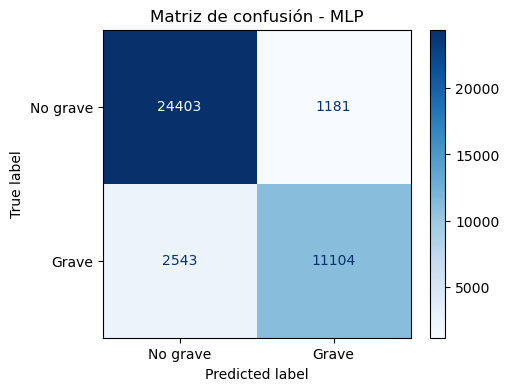

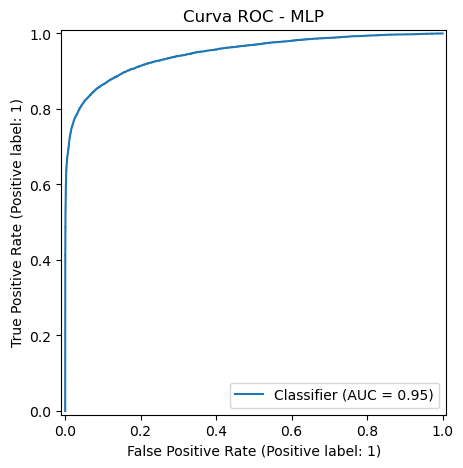

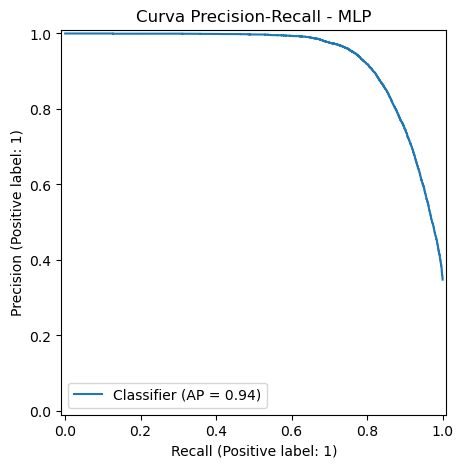

In [59]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
import matplotlib.pyplot as plt

# Predicciones y probabilidades
y_pred = mlp.predict(X_test_scaled_imputed)
y_proba = mlp.predict_proba(X_test_scaled_imputed)[:, 1]

# Métricas principales
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

print("=== MÉTRICAS MLP ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"PR-AUC:    {pr_auc:.4f}")

print("\n=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_test, y_pred, target_names=["No grave", "Grave"], zero_division=0))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["No grave", "Grave"],
    cmap="Blues",
    ax=ax
)
plt.title("Matriz de confusión - MLP")
plt.show()

# Curva ROC
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax)
plt.title("Curva ROC - MLP")
plt.show()

# Curva Precision-Recall
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=ax)
plt.title("Curva Precision-Recall - MLP")
plt.show()

En la fase de evaluación, el modelo de perceptrón multicapa (MLP) mostró un desempeño global sólido para la tarea de clasificación de la gravedad de los siniestros. En el conjunto de prueba, se obtuvo una exactitud (accuracy) de 0.9051, lo que indica que aproximadamente el 90.5% de los casos fueron correctamente clasificados. Sin embargo, dado el ligero desbalance entre clases (alrededor de 65% no graves y 35% graves), se complementó este análisis con métricas más informativas como precisión, recall y F1-score.

Para la clase de interés (“Grave”), el modelo alcanzó una precisión de 0.9039, lo que significa que cuando el modelo predice un siniestro como grave, acierta en más del 90% de los casos. Por otro lado, el recall fue de 0.8137, indicando que el modelo logra identificar aproximadamente el 81% de los siniestros realmente graves. Esta diferencia entre precisión y recall sugiere que el modelo es conservador al clasificar casos como graves: evita falsos positivos, pero aún deja escapar algunos casos críticos (falsos negativos).

El análisis de la matriz de confusión permite profundizar en estos resultados, se observa que el modelo clasifica correctamente 24,403 siniestros no graves y 11,104 siniestros graves, mientras que comete 1,181 falsos positivos (casos no graves clasificados como graves) y 2,543 falsos negativos (siniestros graves no detectados). Desde una perspectiva aplicada, estos últimos son especialmente relevantes, ya que representan eventos de alta severidad que el modelo no logra anticipar, no obstante, la proporción de aciertos sigue siendo considerablemente alta en ambas clases.

De manera complementaria, la curva Precision-Recall alcanza un área (PR-AUC) de 0.9359, lo cual es particularmente relevante en contextos con desbalance de clases, confirmando que el modelo mantiene una alta precisión incluso cuando se exige un mayor nivel de recuperación de casos positivos.

In [158]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)

print(f"Especificidad (No grave): {specificity:.4f}")
print(f"Sensibilidad / Recall (Grave): {sensitivity:.4f}")
print(f"Falsos negativos graves: {fn}")
print(f"Falsos positivos graves: {fp}")

Especificidad (No grave): 0.9538
Sensibilidad / Recall (Grave): 0.8137
Falsos negativos graves: 2543
Falsos positivos graves: 1181


Más allá de la exactitud global, evaluamos la capacidad del modelo para detectar siniestros graves, minimizando falsos negativos, ya que esos casos son los más críticos en un sistema de apoyo a la decisión.

En conjunto, estos resultados evidencian que el modelo MLP logra capturar de manera efectiva las relaciones no lineales entre variables contextuales (clima, calendario), características del siniestro (tipo, ubicación) y variables agregadas (vehículos, actores, causas), aunque existe un margen de mejora en la detección de todos los casos graves, el modelo presenta un desempeño robusto y consistente, adecuado como base para un sistema de apoyo a la toma de decisiones en el análisis de siniestros viales.

### **Análisis de hiperparámetros del MLP**

In [60]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)
import pandas as pd

configuraciones_mlp = [
    {
        "nombre": "MLP_1",
        "hidden_layer_sizes": (64,),
        "activation": "relu",
        "max_iter": 50,
        "alpha": 0.0001
    },
    {
        "nombre": "MLP_2",
        "hidden_layer_sizes": (64, 32),
        "activation": "relu",
        "max_iter": 50,
        "alpha": 0.0001
    },
    {
        "nombre": "MLP_3",
        "hidden_layer_sizes": (128, 64),
        "activation": "relu",
        "max_iter": 100,
        "alpha": 0.0001
    },
    {
        "nombre": "MLP_4",
        "hidden_layer_sizes": (128, 64),
        "activation": "relu",
        "max_iter": 150,
        "alpha": 0.0001
    },
    {
        "nombre": "MLP_5",
        "hidden_layer_sizes": (128, 64, 32),
        "activation": "relu",
        "max_iter": 150,
        "alpha": 0.0001
    }
]

resultados_mlp = []

for config in configuraciones_mlp:
    modelo = MLPClassifier(
        hidden_layer_sizes=config["hidden_layer_sizes"],
        activation=config["activation"],
        solver="adam",
        alpha=config["alpha"],
        learning_rate_init=0.001,
        batch_size=256,
        max_iter=config["max_iter"],
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=42
    )

    modelo.fit(X_train_scaled_imputed, y_train)

    y_pred = modelo.predict(X_test_scaled_imputed)
    y_proba = modelo.predict_proba(X_test_scaled_imputed)[:, 1]

    resultados_mlp.append({
        "Modelo": config["nombre"],
        "Capas": str(config["hidden_layer_sizes"]),
        "Activación": config["activation"],
        "Max_iter": config["max_iter"],
        "Alpha": config["alpha"],
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1_score": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_proba),
        "PR_AUC": average_precision_score(y_test, y_proba)
    })

df_resultados_mlp = pd.DataFrame(resultados_mlp)
df_resultados_mlp = df_resultados_mlp.sort_values(by="F1_score", ascending=False).reset_index(drop=True)

df_resultados_mlp

,Modelo,Capas,Activación,Max_iter,Alpha,Accuracy,Precision,Recall,F1_score,ROC_AUC,PR_AUC
0,MLP_5,"(128, 64, 32)",relu,150,0.0001,0.912442,0.928643,0.810581,0.865605,0.955457,0.942976
1,MLP_1,"(64,)",relu,50,0.0001,0.911906,0.923672,0.814025,0.865389,0.954806,0.942023
2,MLP_3,"(128, 64)",relu,100,0.0001,0.912289,0.929980,0.808749,0.865138,0.955715,0.943269
3,MLP_4,"(128, 64)",relu,150,0.0001,0.912289,0.929980,0.808749,0.865138,0.955715,0.943269
4,MLP_2,"(64, 32)",relu,50,0.0001,0.911244,0.929664,0.805818,0.863322,0.954229,0.941840


El análisis de hiperparámetros mostró que las distintas configuraciones del MLP producen desempeños similares, lo cual sugiere estabilidad del enfoque propuesto. Aun así, se identificó una configuración ligeramente superior, con mejoras consistentes en F1-score, ROC-AUC y PR-AUC frente al modelo base.

Aunque las diferencias entre configuraciones fueron reducidas, se seleccionó la configuración MLP_5 con arquitectura (128, 64, 32) y 150 iteraciones, ya que obtuvo el mejor F1-score y mantuvo valores altos de ROC-AUC y PR-AUC, lo que indica un mejor equilibrio entre precisión y recuperación para la clase grave.

In [61]:
from sklearn.neural_network import MLPClassifier

mlp_final = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    learning_rate_init=0.001,
    batch_size=256,
    max_iter=150,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42
)

mlp_final.fit(X_train_scaled_imputed, y_train)

y_pred_final = mlp_final.predict(X_test_scaled_imputed)
y_proba_final = mlp_final.predict_proba(X_test_scaled_imputed)[:, 1]

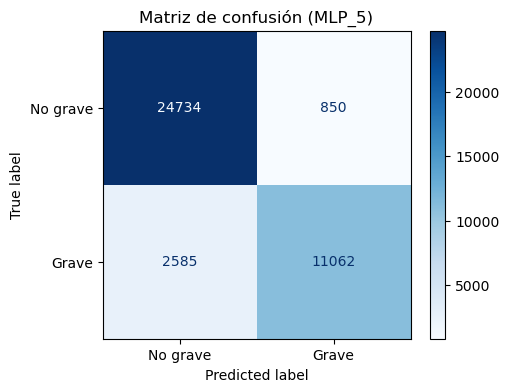

In [62]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_final,
    display_labels=["No grave", "Grave"],
    cmap="Blues",
    ax=ax
)

plt.title("Matriz de confusión (MLP_5)")
plt.show()

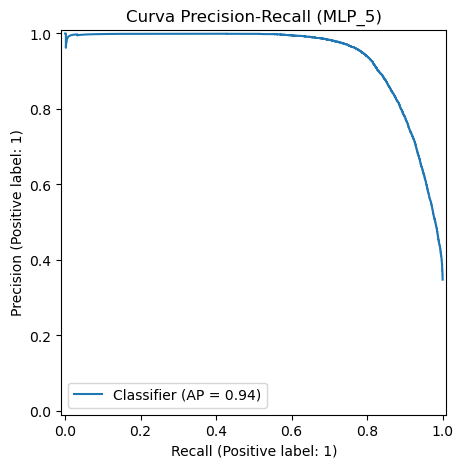

In [63]:
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(6, 5))

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_proba_final,
    ax=ax
)

plt.title("Curva Precision-Recall (MLP_5)")
plt.show()

### **Interfaz prototipo Gradio**

Una vez entrenado el MLP, se integró una interfaz Gradio para que un usuario ingrese condiciones del siniestro y obtenga una clasificación automática de gravedad, junto con la probabilidad asociada. Esto permite mostrar la aplicabilidad del modelo dentro del agente propuesto.

In [60]:
# Dataset base para demo
X_raw_demo = df_modelo.drop(columns=cols_excluir).copy()

In [61]:
print("Columnas usadas en el modelo:", len(X_encoded.columns))
print("Columnas en demo raw:", len(X_raw_demo.columns))

Columnas usadas en el modelo: 206
Columnas en demo raw: 33


El modelo final utiliza una representación expandida de las variables categóricas mediante codificación one-hot, lo que incrementa el número de variables pero permite capturar patrones específicos sin asumir relaciones ordinales.

In [62]:
default_values = {}

for col in X_raw_demo.columns:
    if pd.api.types.is_numeric_dtype(X_raw_demo[col]):
        default_values[col] = float(X_raw_demo[col].median())
    else:
        moda = X_raw_demo[col].mode(dropna=True)
        default_values[col] = moda.iloc[0] if not moda.empty else None

In [63]:
# función de preprocesamiento reutilizable

cols_binarias = [
    'Festivo',
    'Dia_sin_carro',
    'Hubo_Protesta',
    'Es_COVID',
    'Hay_Evento'
]

cols_categoricas_codificadas = [
    'CLASE',
    'CODIGO_LOCALIDAD',
    'DISENO_LUGAR',
    'clase_vehiculo_principal',
    'servicio_principal',
    'modalidad_principal',
    'codigo_causa_principal'
]

feature_columns = X_encoded.columns.tolist()

def transformar_para_modelo(df_input):
    df = df_input.copy()

    # ---- HORA
    df['HORA'] = pd.to_datetime(df['HORA'].astype(str), format='%H:%M', errors='coerce').dt.hour

    # ---- FECHA y derivados
    fecha = pd.to_datetime(df['FECHA'], errors='coerce')
    df['mes'] = fecha.dt.month
    df['dia_mes'] = fecha.dt.day
    df['anio'] = fecha.dt.year
    df['dia_anio'] = fecha.dt.dayofyear
    df['fin_de_semana'] = fecha.dt.dayofweek.isin([5, 6]).astype(int)

    # Eliminar FECHA original
    df = df.drop(columns=['FECHA'])

    # ---- Binarias SI/NO
    for col in cols_binarias:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.upper()
            .map({'SI': 1, 'NO': 0})
        )

    # ---- Convertir ciertas columnas a numéricas primero
    numeric_force_cols = [
        'CHOQUE', 'OBJETO_FIJO',
        'precip_promedio_bogota',
        'num_actores', 'edad_promedio_actor',
        'num_hombres', 'num_mujeres',
        'num_vehiculos', 'num_en_fuga',
        'num_causas_registradas'
    ]

    for col in numeric_force_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # ---- Códigos categóricos: numéricos pero tratados como categoría
    for col in cols_categoricas_codificadas:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64').astype('object')

    # ---- Otras categóricas
    for col in ['Dia_Semana', 'condicion_principal']:
        df[col] = df[col].astype('object')

    # ---- One-hot
    df_encoded = pd.get_dummies(df, drop_first=True)

    # ---- Alinear columnas exactamente igual al entrenamiento
    df_encoded = df_encoded.reindex(columns=feature_columns, fill_value=0)

    # ---- Forzar todo a numérico
    df_encoded = df_encoded.apply(pd.to_numeric, errors='coerce')

    return df_encoded

In [64]:
# función de predicción

def predecir_gravedad(
    FECHA, HORA, CLASE, CHOQUE, OBJETO_FIJO, CODIGO_LOCALIDAD, DISENO_LUGAR,
    precip_promedio_bogota, Festivo, Dia_sin_carro, Hubo_Protesta, Es_COVID, Hay_Evento,
    Dia_Semana, num_actores, edad_promedio_actor, num_hombres, num_mujeres,
    num_vehiculos, num_en_fuga, condicion_principal, clase_vehiculo_principal,
    servicio_principal, modalidad_principal, codigo_causa_principal, num_causas_registradas
):
    try:
        fila = default_values.copy()

        fila.update({
            'FECHA': FECHA,
            'HORA': HORA,
            'CLASE': CLASE,
            'CHOQUE': CHOQUE,
            'OBJETO_FIJO': OBJETO_FIJO,
            'CODIGO_LOCALIDAD': CODIGO_LOCALIDAD,
            'DISENO_LUGAR': DISENO_LUGAR,
            'precip_promedio_bogota': precip_promedio_bogota,
            'Festivo': Festivo,
            'Dia_sin_carro': Dia_sin_carro,
            'Hubo_Protesta': Hubo_Protesta,
            'Es_COVID': Es_COVID,
            'Hay_Evento': Hay_Evento,
            'Dia_Semana': Dia_Semana,
            'num_actores': num_actores,
            'edad_promedio_actor': edad_promedio_actor,
            'num_hombres': num_hombres,
            'num_mujeres': num_mujeres,
            'num_vehiculos': num_vehiculos,
            'num_en_fuga': num_en_fuga,
            'condicion_principal': condicion_principal,
            'clase_vehiculo_principal': clase_vehiculo_principal,
            'servicio_principal': servicio_principal,
            'modalidad_principal': modalidad_principal,
            'codigo_causa_principal': codigo_causa_principal,
            'num_causas_registradas': num_causas_registradas
        })

        df_user = pd.DataFrame([fila])

        X_user = transformar_para_modelo(df_user)

        X_user_scaled = scaler.transform(X_user)
        X_user_final = imputer.transform(X_user_scaled)

        proba_grave = mlp.predict_proba(X_user_final)[0, 1]
        pred = int(proba_grave >= 0.5)
        etiqueta = "Grave" if pred == 1 else "No grave"

        return (
            {"No grave": float(1 - proba_grave), "Grave": float(proba_grave)},
            f"Predicción final: {etiqueta}. Probabilidad de gravedad: {proba_grave:.2%}"
        )

    except Exception as e:
        return (
            {"Error": 1.0},
            f"Se produjo un error en la predicción: {str(e)}"
        )

**Prototipo Funcional**

In [65]:
resultado = predecir_gravedad(
    FECHA="2018-12-31",
    HORA="01:30",
    CLASE="1",
    CHOQUE=1,
    OBJETO_FIJO=0,
    CODIGO_LOCALIDAD="14",
    DISENO_LUGAR="1",
    precip_promedio_bogota=0.5,
    Festivo="NO",
    Dia_sin_carro="NO",
    Hubo_Protesta="NO",
    Es_COVID="NO",
    Hay_Evento="NO",
    Dia_Semana="Lunes",
    num_actores=2,
    edad_promedio_actor=35,
    num_hombres=1,
    num_mujeres=1,
    num_vehiculos=2,
    num_en_fuga=0,
    condicion_principal=str(X_raw_demo['condicion_principal'].mode()[0]),
    clase_vehiculo_principal=str(int(X_raw_demo['clase_vehiculo_principal'].mode()[0])),
    servicio_principal=str(int(X_raw_demo['servicio_principal'].mode()[0])),
    modalidad_principal=str(int(X_raw_demo['modalidad_principal'].mode()[0])),
    codigo_causa_principal=str(int(X_raw_demo['codigo_causa_principal'].mode()[0])),
    num_causas_registradas=1
)

resultado

({'No grave': 0.19514804720572354, 'Grave': 0.8048519527942765},
 'Predicción final: Grave. Probabilidad de gravedad: 80.49%')

El modelo puede utilizarse para simular distintos escenarios y analizar cómo cambia la probabilidad de gravedad bajo diferentes condiciones. Por ejemplo, se pueden fijar ciertas variables (como la localidad o el tipo de vía) y variar otras (hora, clima, día de la semana) para identificar combinaciones que incrementan el riesgo. Esto permite detectar patrones como horarios críticos, condiciones climáticas asociadas a mayor severidad o zonas donde los siniestros tienden a ser más graves. En este sentido, el modelo no solo predice, sino que también sirve como herramienta exploratoria para apoyar estrategias de prevención y planificación urbana.

In [66]:
# Diccionario de localidades
dic_localidad = df_diccionario_maestro[
    (df_diccionario_maestro['CAMPO'] == 'CODIGO_LOCALIDAD')
]

dic_localidad[['CODIGO', 'DESCRIPCION']].sort_values(by='CODIGO')

,CODIGO,DESCRIPCION
25,1,Usaquén
26,2,Chapinero
27,3,Santa Fe
28,4,San Cristóbal
29,5,Usme
30,6,Tunjuelito
31,7,Bosa
32,8,Kennedy
33,9,Fontibón
34,10,Engativá


In [67]:
# Diccionario de diseño del lugar
dic_diseno = df_diccionario_maestro[
    (df_diccionario_maestro['CAMPO'] == 'DISENO_LUGAR')
]

dic_diseno[['CODIGO', 'DESCRIPCION']].sort_values(by='CODIGO')

,CODIGO,DESCRIPCION
45,1,Tramo de Via
46,2,Interseccion
47,3,Via peatonal
48,4,Paso elevado
49,5,Paso inferior
50,6,Paso a nivel
51,7,Glorieta
52,8,Puente
53,9,Via troncal
54,10,Lote o predio


In [174]:
# interfaz en Gradio
import gradio as gr

demo = gr.Interface(
    fn=predecir_gravedad,
    inputs=[
        gr.Textbox(label="Fecha (YYYY-MM-DD)", value="2018-06-11"),
        gr.Textbox(label="Hora (HH:MM)", value="08:30"),
        gr.Dropdown(choices=sorted(X_raw_demo['CLASE'].dropna().astype(int).astype(str).unique().tolist()), label="Clase del siniestro", value=str(int(X_raw_demo['CLASE'].mode()[0]))),
        gr.Number(label="Choque", value=1),
        gr.Number(label="Objeto fijo", value=0),
        gr.Dropdown(choices=sorted(X_raw_demo['CODIGO_LOCALIDAD'].dropna().astype(int).astype(str).unique().tolist()), label="Código localidad", value=str(int(X_raw_demo['CODIGO_LOCALIDAD'].mode()[0]))),
        gr.Dropdown(choices=sorted(X_raw_demo['DISENO_LUGAR'].dropna().astype(int).astype(str).unique().tolist()), label="Diseño del lugar", value=str(int(X_raw_demo['DISENO_LUGAR'].mode()[0]))),
        gr.Number(label="Precipitación promedio Bogotá", value=float(X_raw_demo['precip_promedio_bogota'].median())),
        gr.Radio(["SI", "NO"], label="Festivo", value="NO"),
        gr.Radio(["SI", "NO"], label="Día sin carro", value="NO"),
        gr.Radio(["SI", "NO"], label="Hubo protesta", value="NO"),
        gr.Radio(["SI", "NO"], label="Es COVID", value="NO"),
        gr.Radio(["SI", "NO"], label="Hay evento", value="NO"),
        gr.Dropdown(choices=sorted(X_raw_demo['Dia_Semana'].dropna().astype(str).unique().tolist()), label="Día de la semana", value=str(X_raw_demo['Dia_Semana'].mode()[0])),
        gr.Number(label="Número de actores", value=float(X_raw_demo['num_actores'].median())),
        gr.Number(label="Edad promedio actor", value=float(X_raw_demo['edad_promedio_actor'].median())),
        gr.Number(label="Número de hombres", value=float(X_raw_demo['num_hombres'].median())),
        gr.Number(label="Número de mujeres", value=float(X_raw_demo['num_mujeres'].median())),
        gr.Number(label="Número de vehículos", value=float(X_raw_demo['num_vehiculos'].median())),
        gr.Number(label="Número en fuga", value=float(X_raw_demo['num_en_fuga'].median())),
        gr.Dropdown(choices=sorted(X_raw_demo['condicion_principal'].dropna().astype(str).unique().tolist()), label="Condición principal", value=str(X_raw_demo['condicion_principal'].mode()[0])),
        gr.Dropdown(choices=sorted(X_raw_demo['clase_vehiculo_principal'].dropna().astype(int).astype(str).unique().tolist()), label="Clase vehículo principal", value=str(int(X_raw_demo['clase_vehiculo_principal'].mode()[0]))),
        gr.Dropdown(choices=sorted(X_raw_demo['servicio_principal'].dropna().astype(int).astype(str).unique().tolist()), label="Servicio principal", value=str(int(X_raw_demo['servicio_principal'].mode()[0]))),
        gr.Dropdown(choices=sorted(X_raw_demo['modalidad_principal'].dropna().astype(int).astype(str).unique().tolist()), label="Modalidad principal", value=str(int(X_raw_demo['modalidad_principal'].mode()[0]))),
        gr.Dropdown(choices=sorted(X_raw_demo['codigo_causa_principal'].dropna().astype(int).astype(str).unique().tolist()), label="Código causa principal", value=str(int(X_raw_demo['codigo_causa_principal'].mode()[0]))),
        gr.Number(label="Número de causas registradas", value=float(X_raw_demo['num_causas_registradas'].median()))
    ],
    outputs=[
        gr.Label(label="Probabilidades"),
        gr.Textbox(label="Resultado")
    ],
    title="SiniBogotá - Predicción de gravedad del siniestro",
    description="Prototipo de apoyo para estimar si un siniestro sería grave o no grave a partir de variables contextuales, operacionales y de entorno."
)

demo.launch()

IMPORTANT: You are using gradio version 3.24.1, however version 4.44.1 is available, please upgrade.
--------
Running on local URL:  http://127.0.0.1:7864

To create a public link, set `share=True` in `launch()`.
